In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection",
    embedding_function=embeddings
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [4]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {"context": docs}

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [6]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

generate_llm = ChatOpenAI(model='gpt-4o', max_completion_tokens=100)

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response =rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [7]:
from langsmith import Client
from typing import Literal

client = Client()
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']:
    query = state["query"]
    context = state["context"]
    print(f'context == {context}')
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response: {response}')
    if response['Score'] == 1:
        return 'relevant'
    return 'irrelevant'


In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


rewrite_prompt = PromptTemplate.from_template("""
사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요
질문: {query}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    print(f'rewrite question == {response}')
    return {'query': response}


In [9]:
%pip install -U langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from langchain_tavily import TavilySearch


tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
    # include_answer=True,
    # include_raw_content=True,
    # include_images=True,
    # search_depth="advanced",    
)

def web_search(state: AgentState):
    query = state['query']
    results = tavily_search_tool.invoke(query)
    # results = search_data['results']
    # results = [item for item in search_data['results']]
    print(f'web search == {results}')
    return {'context': results}

In [11]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
# graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [12]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': 'web_search'
    }
)
# graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [13]:
graph = graph_builder.compile()

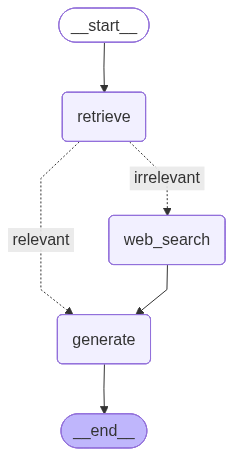

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# initial_state ={'query': '연봉 5천만원인 거주자자 납부해야 하는 소득세는 얼마인가요?'}

# graph.invoke(initial_state)

In [16]:
initial_state ={'query': '역삼역 맛집은?'}

graph.invoke(initial_state)

context == [Document(id='c1ad31e8-6f7f-4ee7-99e7-d260b8bae889', metadata={'article': '제56조의3(전자계산서 발급 전송에 대한 세액공제)'}, page_content='제56조의3(전자계산서 발급 전송에 대한 세액공제) ① 총수입금액 등을 고려하여 대통령령으로 정하는 사업자가 제163조제1항 후단에 따른 전자계산서를 2027년 12월 31일까지 발급(제163조제8항에 따라 전자계산서 발급명세를 국세청장에게 전송하는 경우로 한정한다)하는 경우에는 전자계산서 발급 건수 등을 고려하여 대통령령으로 정하는 금액을 해당 과세기간의 사업소득에 대한 종합소득산출세액에서 공제할 수 있다. 이 경우 공제한도는 연간 100만원으로 한다. <개정 2021. 12. 8., 2024. 12. 31.>\n② 제1항에 따른 세액공제를 적용받으려는 사업자는 제70조 또는 제74조에 따른 과세표준확정신고를 할 때 재정경제부령으로 정하는 전자계산서 발급 세액공제신고서를 납세지 관할 세무서장에게 제출하여야 한다.<개정 2025. 10. 1.>\n[본조신설 2014. 12. 23.]'), Document(id='c89abbdb-43e4-49cc-9a0b-3f884c3e4f40', metadata={'article': '제38조'}, page_content='제38조 삭제 <2006. 12. 30.>\n제3관 귀속연도 및 취득가액 등 <개정 2009. 12. 31.>'), Document(id='7b5049a1-4675-482d-9d8a-cff00a93bbba', metadata={'article': '제79조(사업장 현황의 조사ㆍ확인)'}, page_content='제79조(사업장 현황의 조사ㆍ확인) 제78조에 따른 사업장 현황신고를 받은 사업장 소재지 관할 세무서장 또는 지방국세청장은 대통령령으로 정하는 바에 따라 그 사업장의 현황을 조사ㆍ확인하거나 이에 관한 장부ㆍ서류ㆍ물건 등의 제출 또는 그 밖에 필요한 사항을 명할 수 있

{'query': '역삼역 맛집은?',
 'context': {'query': '역삼역 맛집은?',
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://jdblue2022.tistory.com/entry/%EC%97%AD%EC%82%BC%EC%97%AD-%EB%A7%9B%EC%A7%91-%EB%B2%A0%EC%8A%A4%ED%8A%B810',
    'title': '역삼역 맛집 베스트10 추천 2024 플레이스 맛집',
    'content': '# 역삼역 맛집 베스트10 추천 2024 플레이스 맛집. 오늘은 강남의 중심인 역삼역 근처의 맛집 베스트 10곳을 소개해드리고자 하는데\xa0양대 포털의\xa0플레이스를 중심으로 순위를 취합하여 역삼역 로컬 맛집들과 함께 여러 음식점을\xa0묶어서 역삼\xa0맛집을 정리해드리고자 합니다. 역삼역 맛집 베스트10 음식점 주요 메뉴. 역삼역 맛집 베스트10 음식점 주요 메뉴. 역삼역 이도곰탕 플레이스(구글 평점 4.2). 이어지는 역삼역 맛집은 역삼역 8번 출구 근처에 위치하고 있는 한우곰탕 전문점 이도곰탕 본점입니다. 역삼역 대우부대찌개 플레이스(구글 평점 4.2). 이어지는 역삼역 맛집은 역삼역 6번 출구 근처에 위치하고 있는 부대찌개 전문점 대우부대찌개입니다. 역삼역 호보식당 플레이스(구글 평점 4.4). 역삼역 옛날농장 플레이스(구글 평점 4.0). 역삼역 고갯마루 플레이스(구글 평점 4.2). 이어지는 역삼역 맛집은 역삼역 1번 출구 근처에 위치하고 있는 닭볶음탕 전문점 고갯마루입니다. 역삼역 보슬보슬 플레이스(구글 평점 4.1). 역삼역 고향마을 플레이스(구글 평점 4.2). 역삼역 서울집 플레이스(구글 평점 4.2). 이렇게 오늘은 역삼역 근처의 소문난 맛집 10곳을 네이버와 구글 양대 포털의 플레이스 순위를 기준으로 소개해드렸는데요. 대표적인 오피스 상권으로 회사원들이 집중되어 있는 곳